In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # You can change this font if you prefer
    "axes.labelsize": 14,  # Adjust as needed
    "axes.titlesize": 16,  # Adjust as needed
    "xtick.labelsize": 14,  # Adjust as needed
    "ytick.labelsize": 14,  # Adjust as needed
    "legend.fontsize": 12,  # Adjust as needed
    "figure.figsize": (15, 8),  # Adjust as needed
    "figure.dpi": 600  # Adjust as needed
})
from astropy.io import fits

from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

from getdist import plots, MCSamples

%matplotlib inline

In [11]:
base_dir = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/'
version = 'SP_v1.4_conv'

cov_tau_jk = np.load(base_dir+'/cov_tau_'+version+'_jk.npy')
cov_tau_th = np.load(base_dir+'/cov_tau_'+version+'_th.npy')

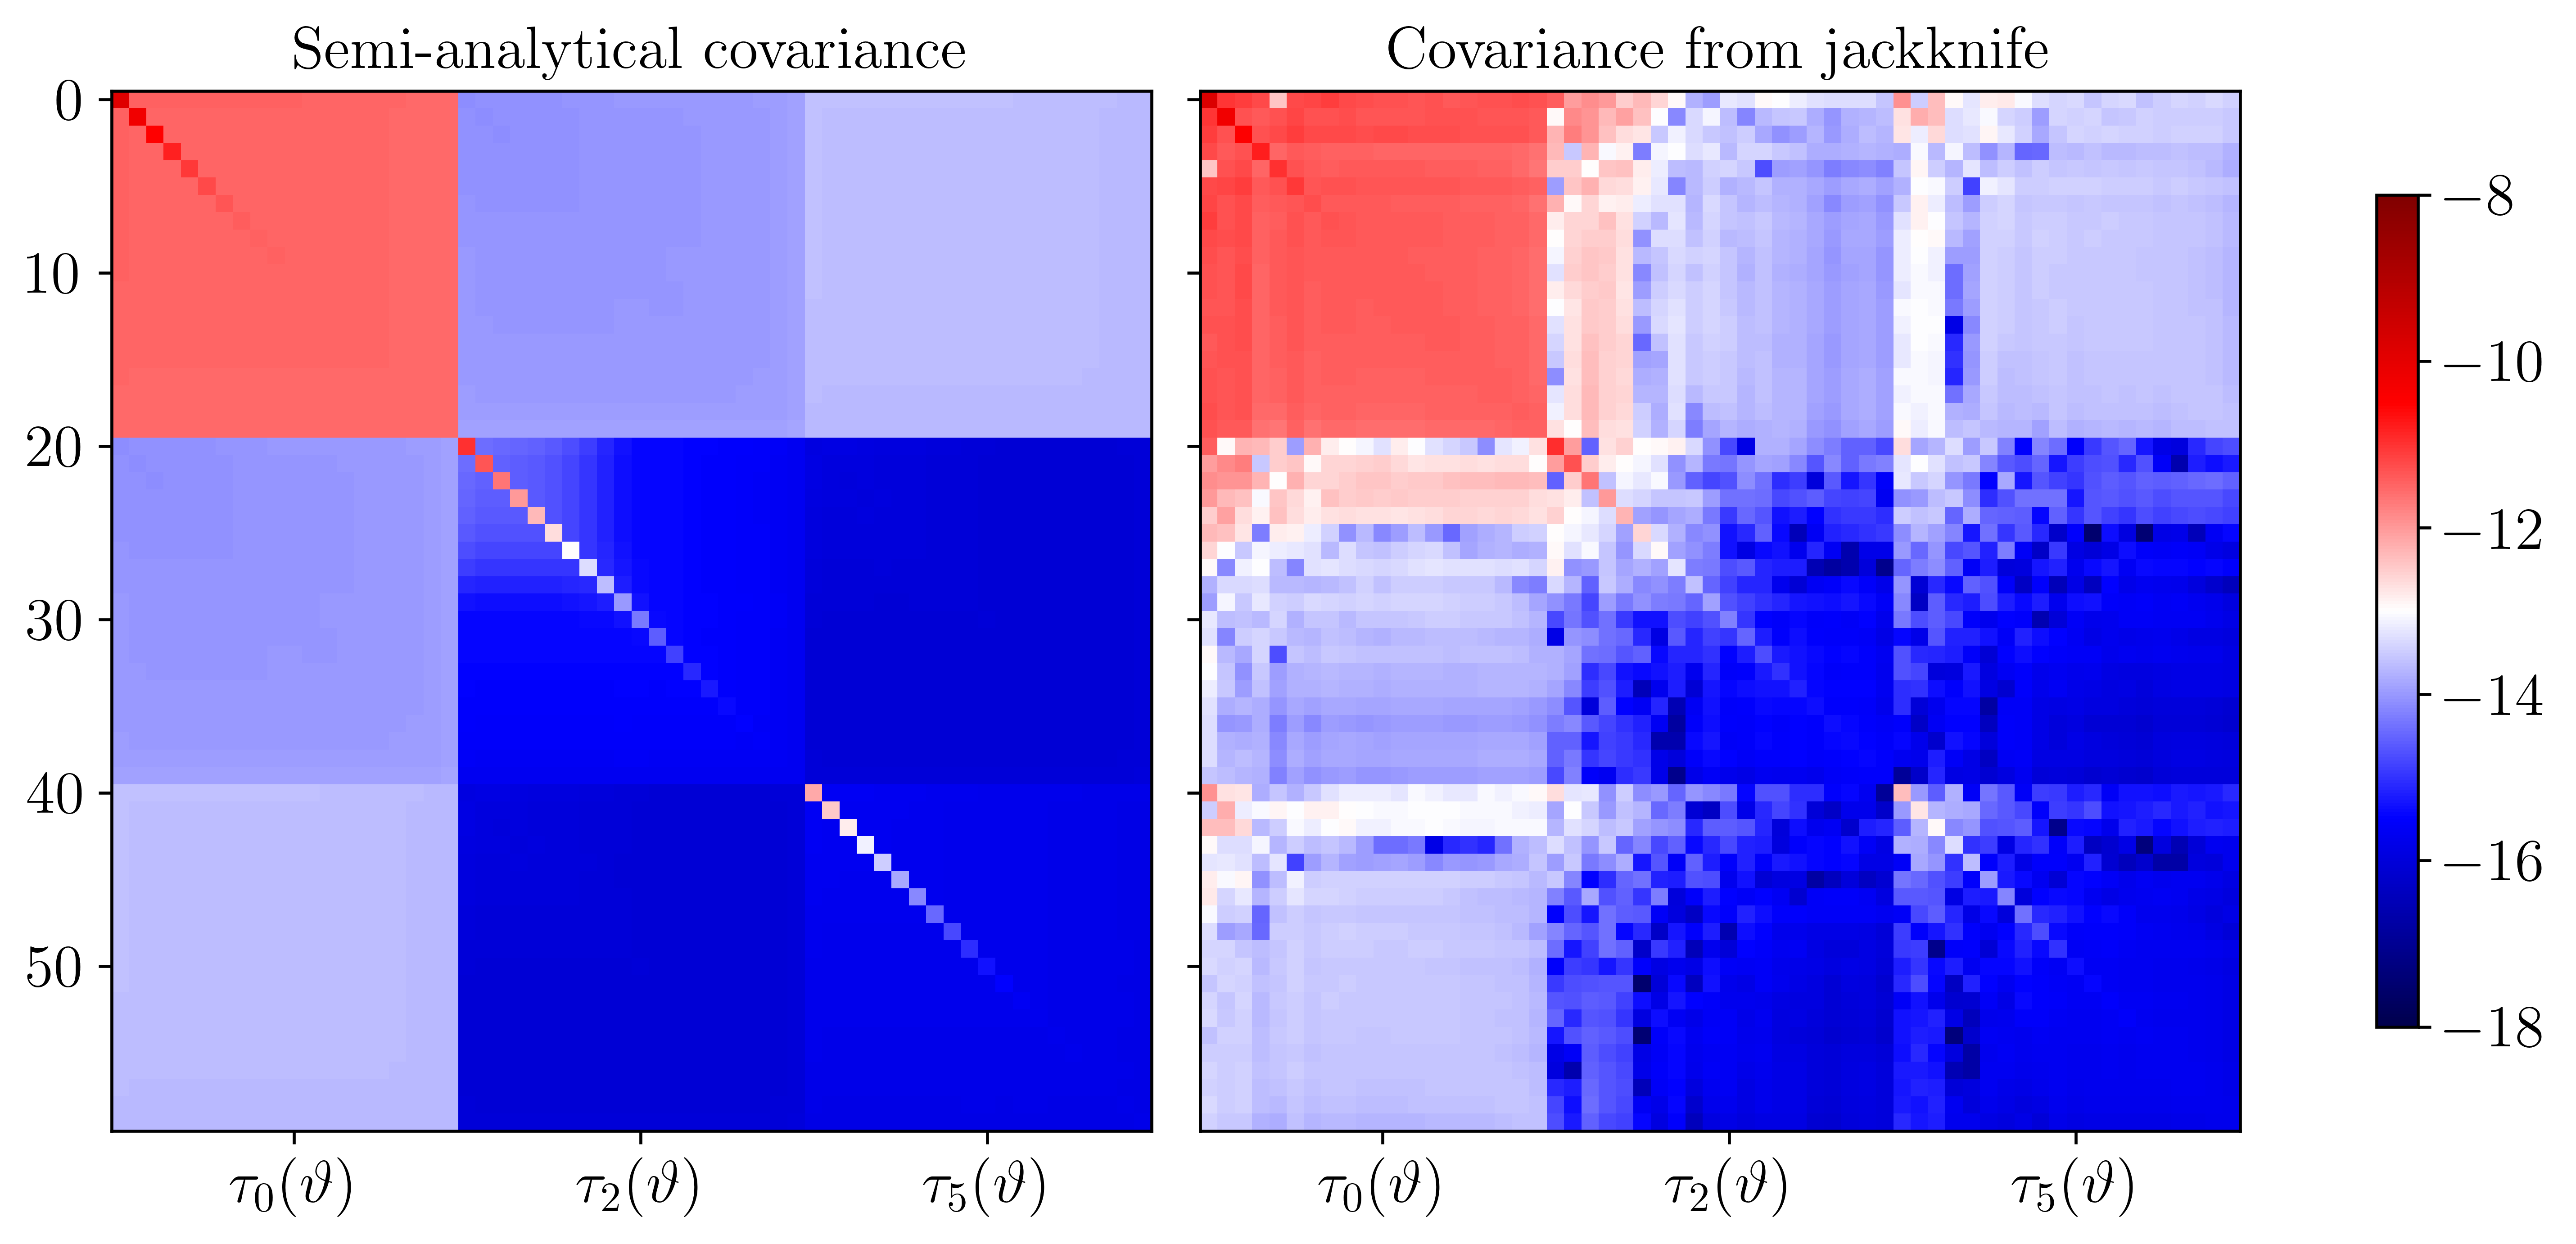

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Second subplot

im2 = axs[1].imshow(np.log10(np.abs(cov_tau_jk)), cmap='seismic', vmin=-18, vmax=-8)
axs[1].set_title("Covariance from jackknife")
axs[1].set_aspect('equal')  # Set equal aspect ratio
axs[1].set_xticks(np.array([10, 30, 50]))
axs[1].set_xticklabels([r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$", r"$\tau_5(\vartheta)$"])

# Third subplot

im3 = axs[0].imshow(np.log10(np.abs(cov_tau_th)), cmap='seismic', vmin=-18, vmax=-8)
axs[0].set_title("Semi-analytical covariance")
axs[0].set_aspect('equal')  # Set equal aspect ratio
axs[0].set_xticks(np.array([10, 30, 50]))
axs[0].set_xticklabels([r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$", r"$\tau_5(\vartheta)$"])

plt.subplots_adjust(wspace=0.)
fig.colorbar(im2, ax = axs, orientation="vertical", shrink=0.8)

plt.show()

In [13]:
corr_tau_jk = np.array(
    [[1/(cov_tau_jk[i,i]*cov_tau_jk[j,j]) for i in range(60)] for j in range(60)]
)

corr_tau_th = np.array(
    [[1/(cov_tau_th[i,i]*cov_tau_th[j,j]) for i in range(60)] for j in range(60)]
)

corr_tau_jk = cov_tau_jk*np.sqrt(corr_tau_jk)
corr_tau_th = cov_tau_th*np.sqrt(corr_tau_th)

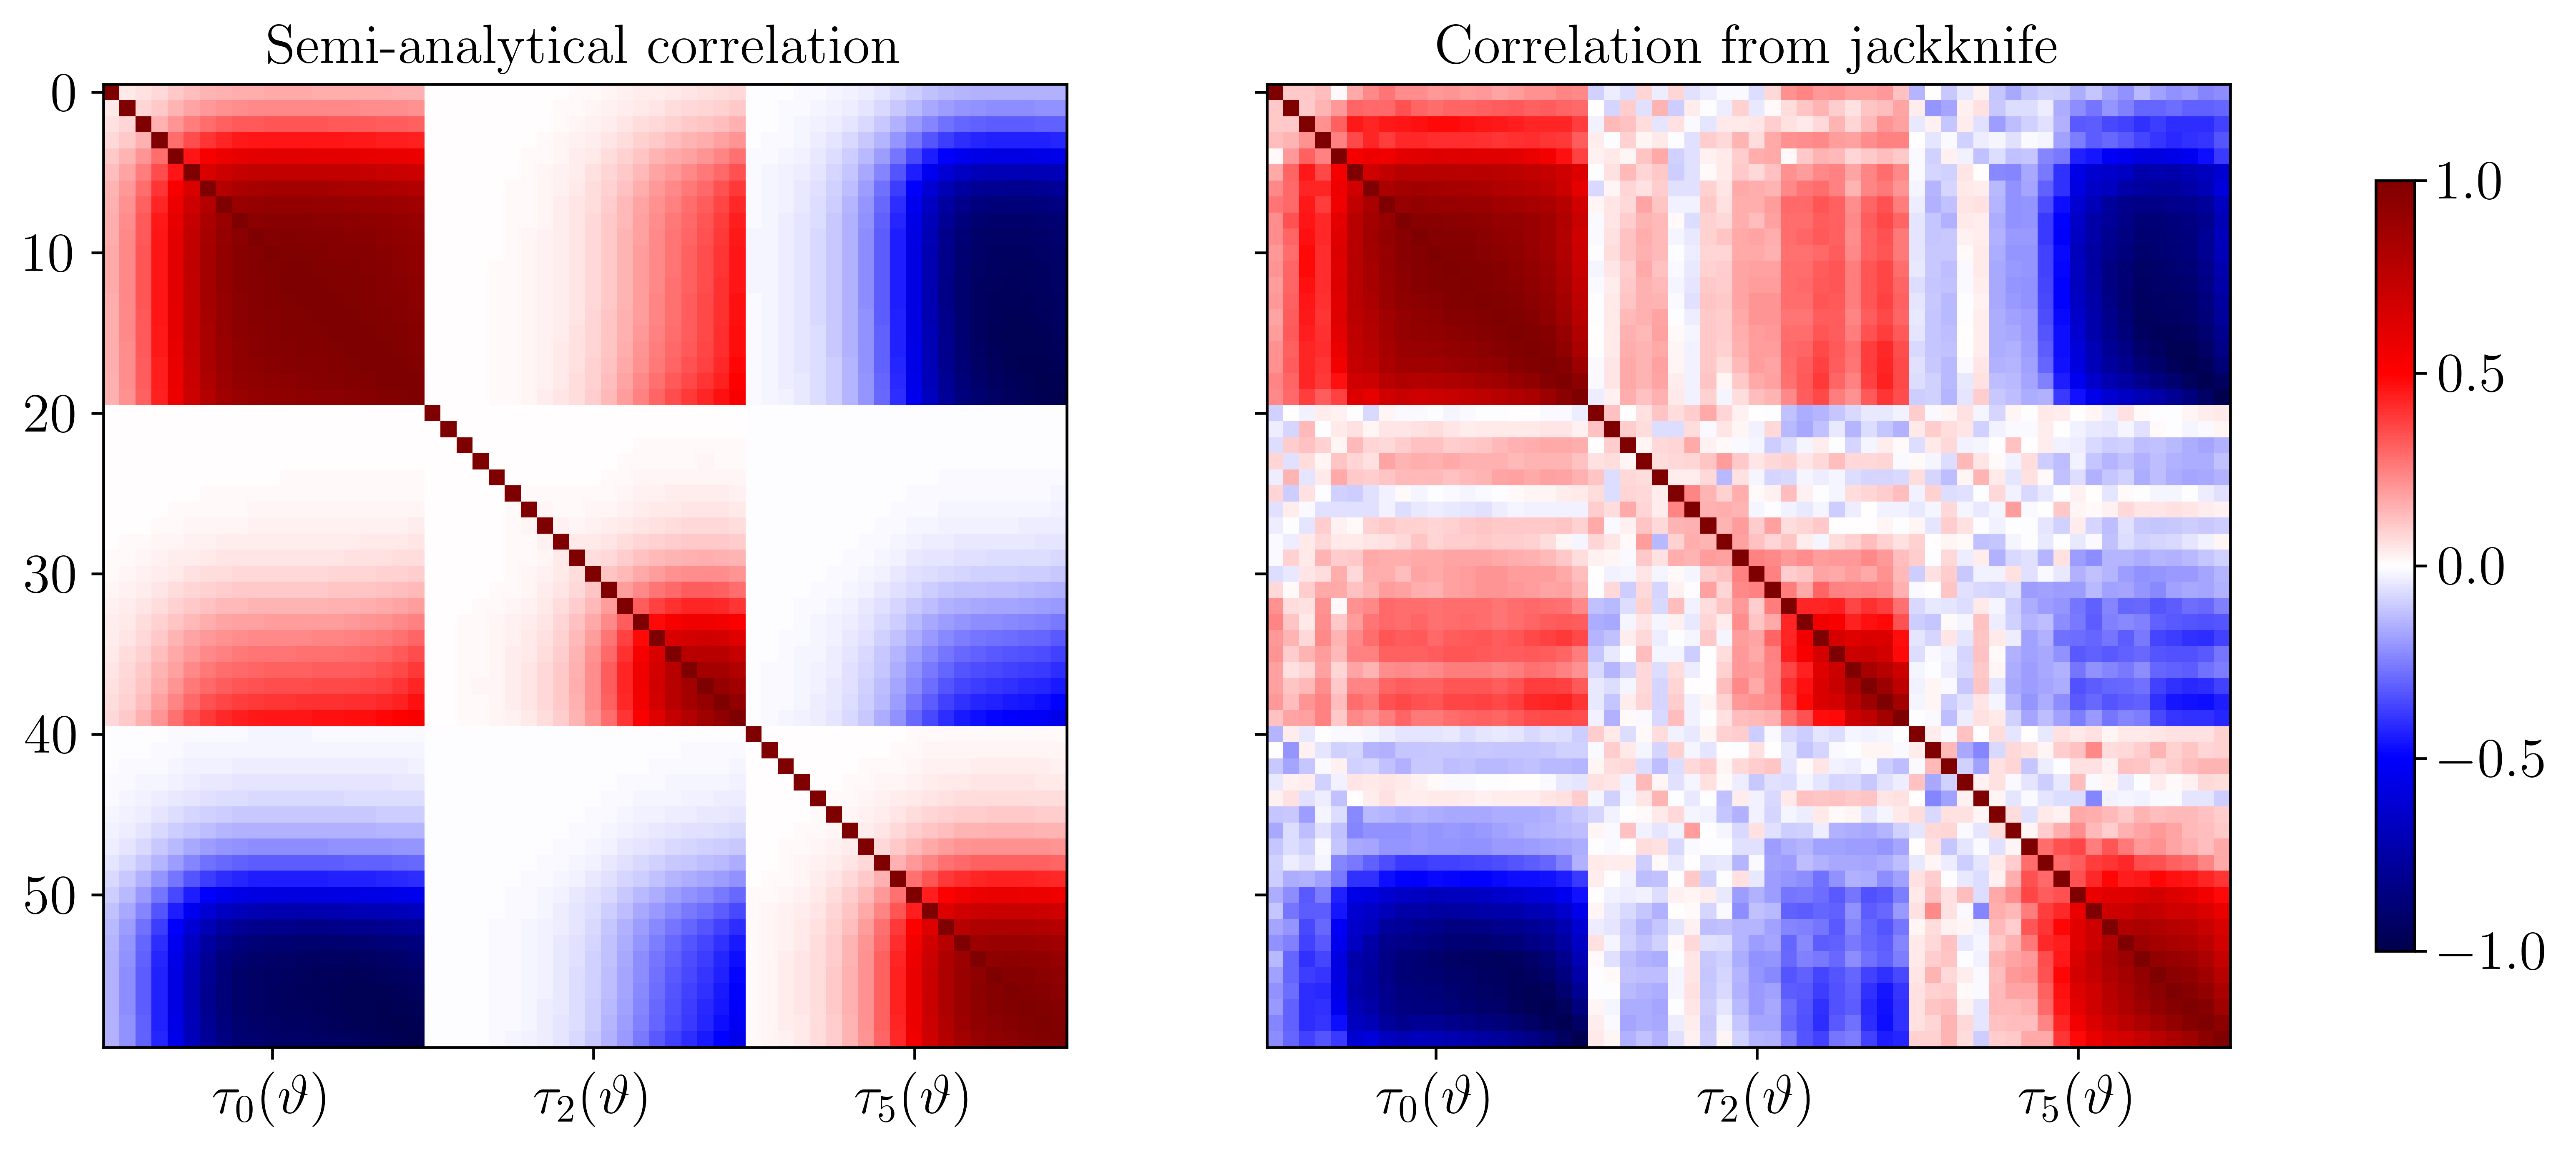

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
# Second subplot

im2 = axs[1].imshow(corr_tau_jk, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title("Correlation from jackknife")
axs[1].set_aspect('equal')  # Set equal aspect ratio
axs[1].set_xticks(np.array([10, 30, 50]))
axs[1].set_xticklabels([r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$", r"$\tau_5(\vartheta)$"])

# Third subplot

im3 = axs[0].imshow(corr_tau_th, cmap='seismic', vmin=-1, vmax=1)
axs[0].set_title("Semi-analytical correlation")
axs[0].set_aspect('equal')  # Set equal aspect ratio
axs[0].set_xticks(np.array([10, 30, 50]))
axs[0].set_xticklabels([r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$", r"$\tau_5(\vartheta)$"])

plt.subplots_adjust(wspace=0.)
fig.colorbar(im2, ax = axs, orientation="vertical", shrink=0.8)

#plt.tight_layout()

plt.show()

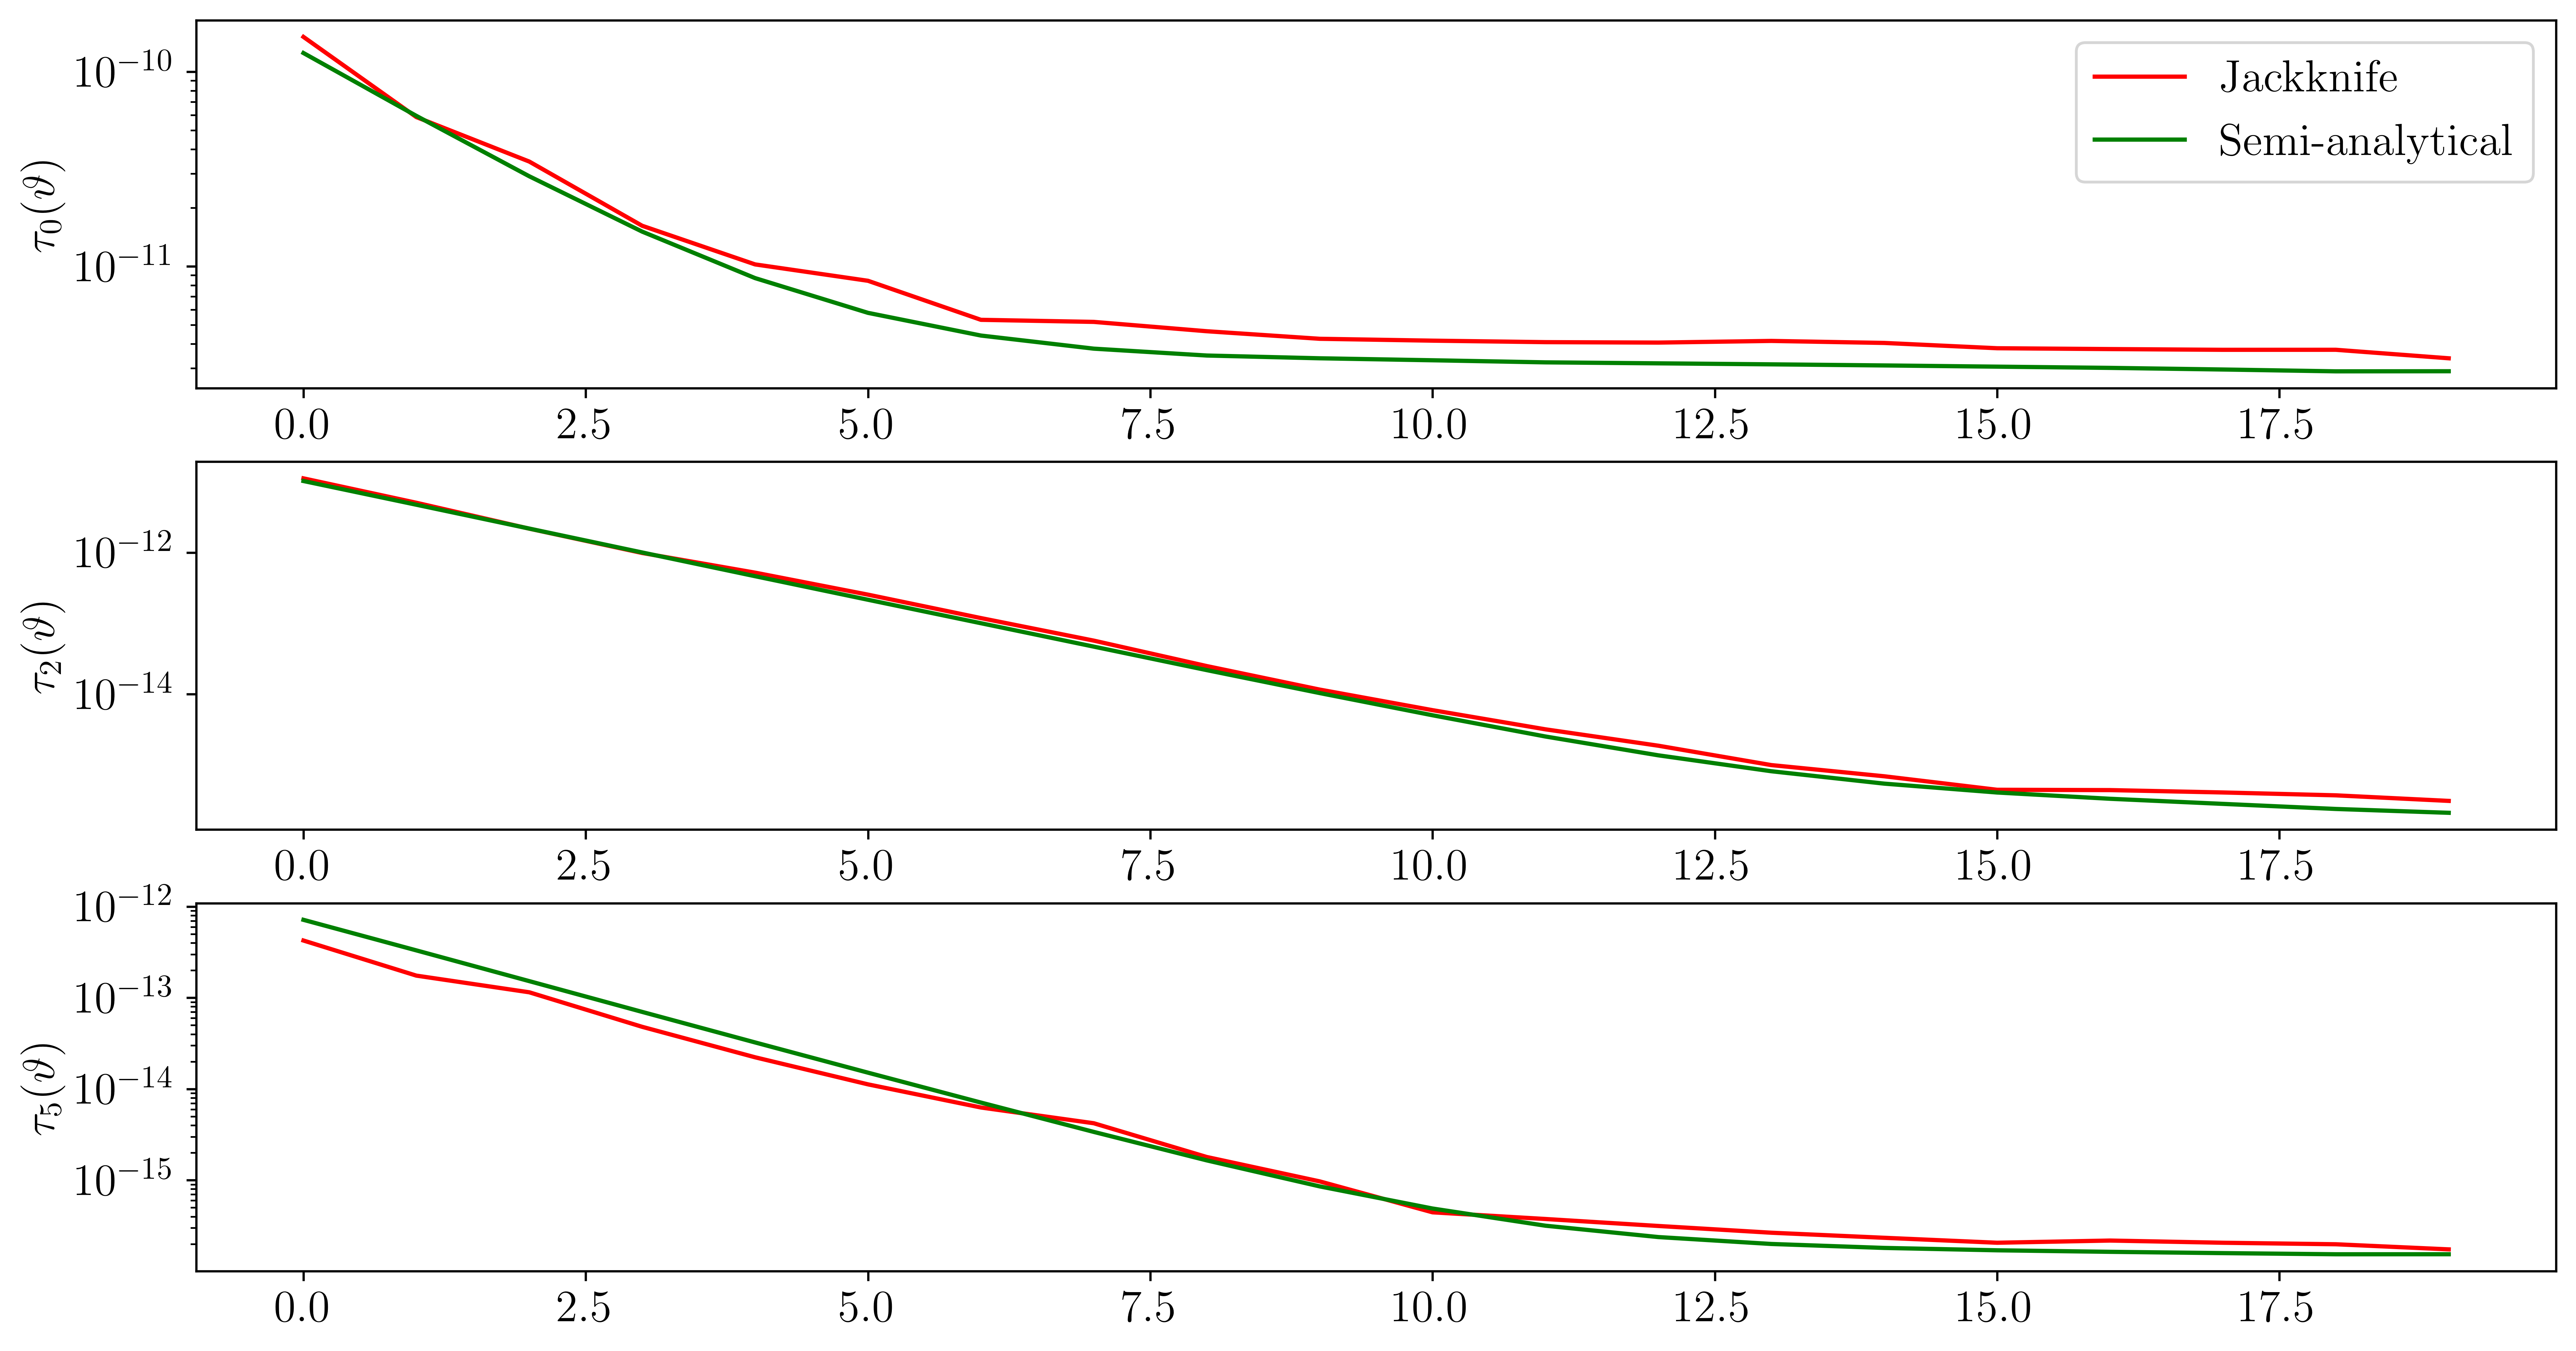

In [15]:
plt.figure()

plt.subplot(311)

plt.plot(np.diag(cov_tau_jk[:20, :20]), c='r', label='Jackknife')
plt.plot(np.diag(cov_tau_th[:20, :20]), c='g', label='Semi-analytical')

plt.yscale('log')
plt.ylabel(r"$\tau_0(\vartheta)$")
plt.legend()

plt.subplot(312)

plt.plot(np.diag(cov_tau_jk[20:40, 20:40]), c='r')
plt.plot(np.diag(cov_tau_th[20:40, 20:40]), c='g')

plt.yscale('log')
plt.ylabel(r"$\tau_2(\vartheta)$")

plt.subplot(313)

plt.plot(np.diag(cov_tau_jk[40:60, 40:60]), c='r')
plt.plot(np.diag(cov_tau_th[40:60, 40:60]), c='g')

plt.yscale('log')
plt.ylabel(r"$\tau_5(\vartheta)$")

plt.show()

In [7]:
#Inference of the xi_sys parameters
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 0.1
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

rho_stats_handler = RhoStat(
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

In [16]:
path_rho = 'rho_stats_'+version+'.fits'
path_tau = 'tau_stats_'+version+'.fits'
path_cov_tau_jk = 'cov_tau_'+version+'_jk.npy'
path_cov_tau_th = 'cov_tau_'+version+'_th.npy'
path_cov_rho = 'cov_rho_'+version+'.npy'

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, base_dir)

psf_fitter.load_rho_stat(path_rho)
psf_fitter.load_tau_stat(path_tau)

psf_fitter.load_covariance(path_cov_tau_jk, cov_type='tau')
psf_fitter.load_covariance(path_cov_rho, cov_type='rho')

samples_jk_lq, _, _ = psf_fitter.get_least_squares_params_samples(npatch=150, apply_debias=True)

psf_fitter.load_covariance(path_cov_tau_th, cov_type='tau')

samples_th_lq, _, _ = psf_fitter.get_least_squares_params_samples(npatch=150, apply_debias=False)

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.


100%|██████████| 10000/10000 [01:12<00:00, 136.99it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0091^+0.0059_0.0060
Parameter: $\beta$=0.9780^+0.0983_0.0990
Parameter: $\eta$=-0.1863^+0.7569_0.7802
Chi square: 73.11047484863163


100%|██████████| 10000/10000 [01:08<00:00, 146.09it/s]

Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0129^+0.0077_0.0079
Parameter: $\beta$=1.1531^+0.0864_0.0922
Parameter: $\eta$=0.0038^+1.0385_1.0391
Chi square: 132.62396626665654


Removed no burn in
Removed no burn in


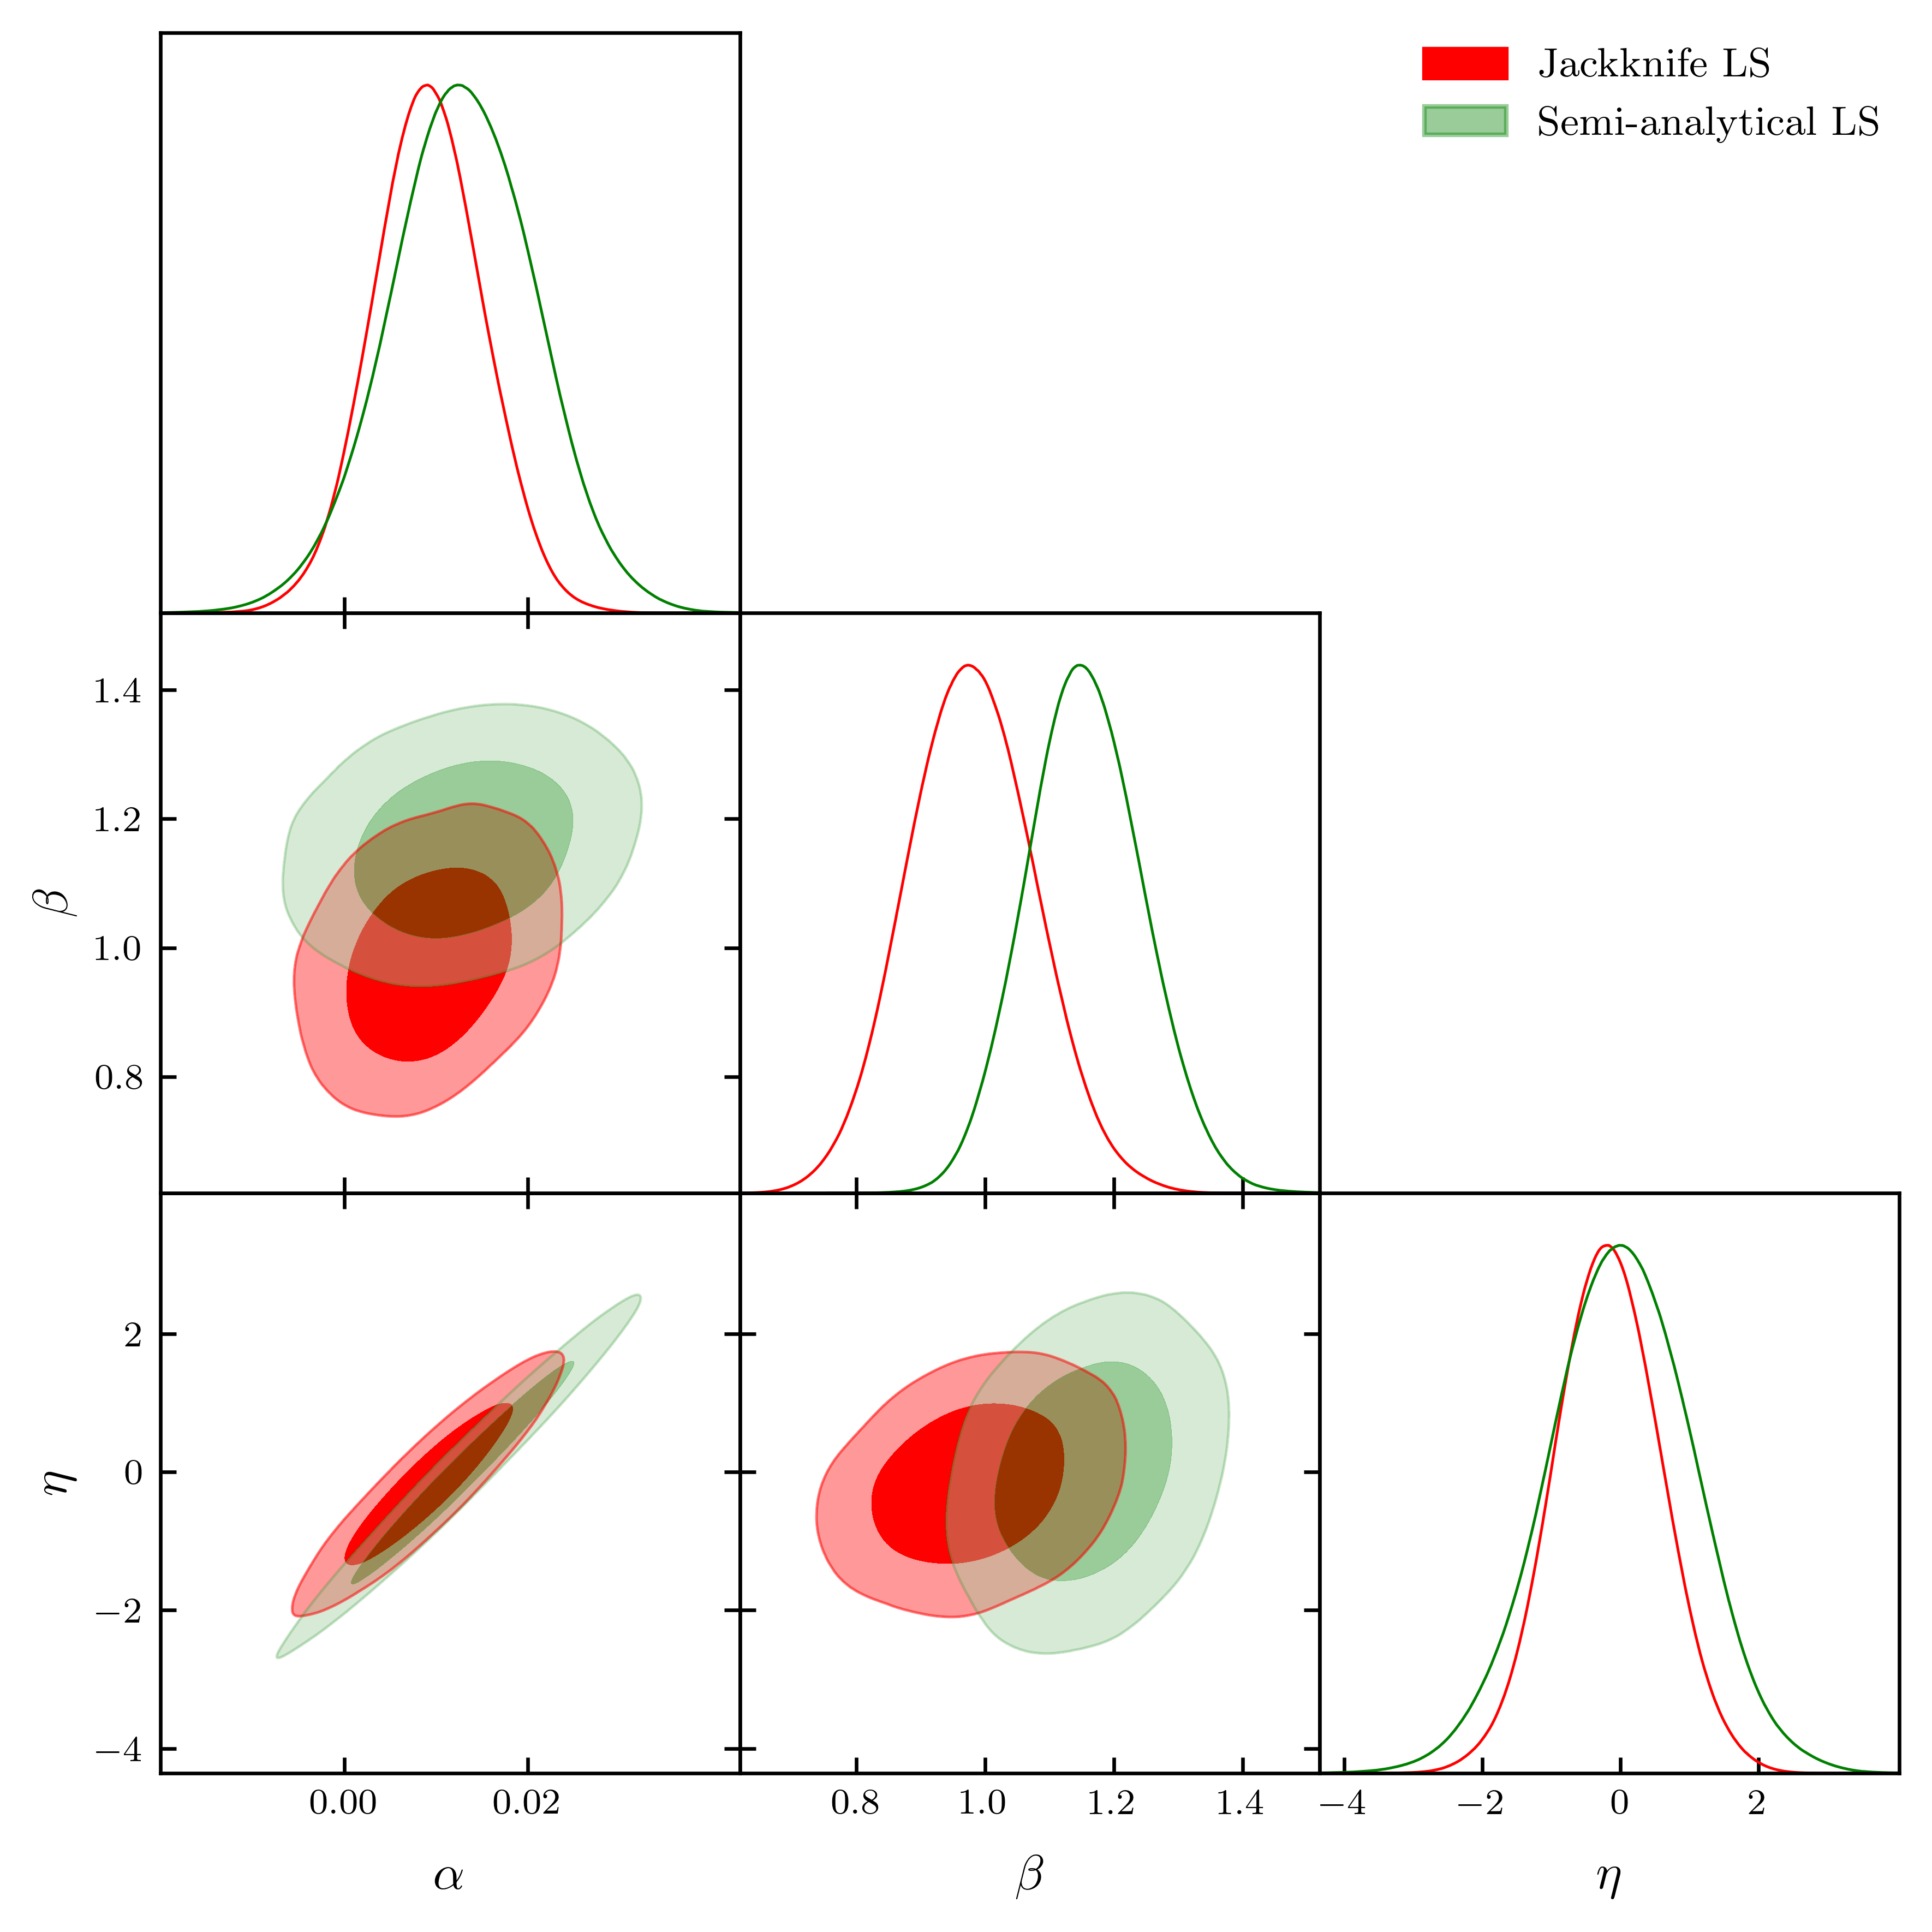

In [17]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add=0.4

samples_jk_gd = MCSamples(samples=samples_jk_lq, names=[r"\alpha", r"\beta", r"\eta"], labels=[r"\alpha", r"\beta", r"\eta"])
samples_th_gd = MCSamples(samples=samples_th_lq, names=[r"\alpha", r"\beta", r"\eta"], labels=[r"\alpha", r"\beta", r"\eta"])

g.triangle_plot([samples_jk_gd, samples_th_gd],
                filled=True,
                legend_labels=[r'Jackknife LS', r'Semi-analytical LS'],
                legend_loc='upper right',
                line_args=[
                    {'color': 'r'},
                    {'color': 'g'}
                ],
                contour_colors=['r', 'g'])

plt.show()

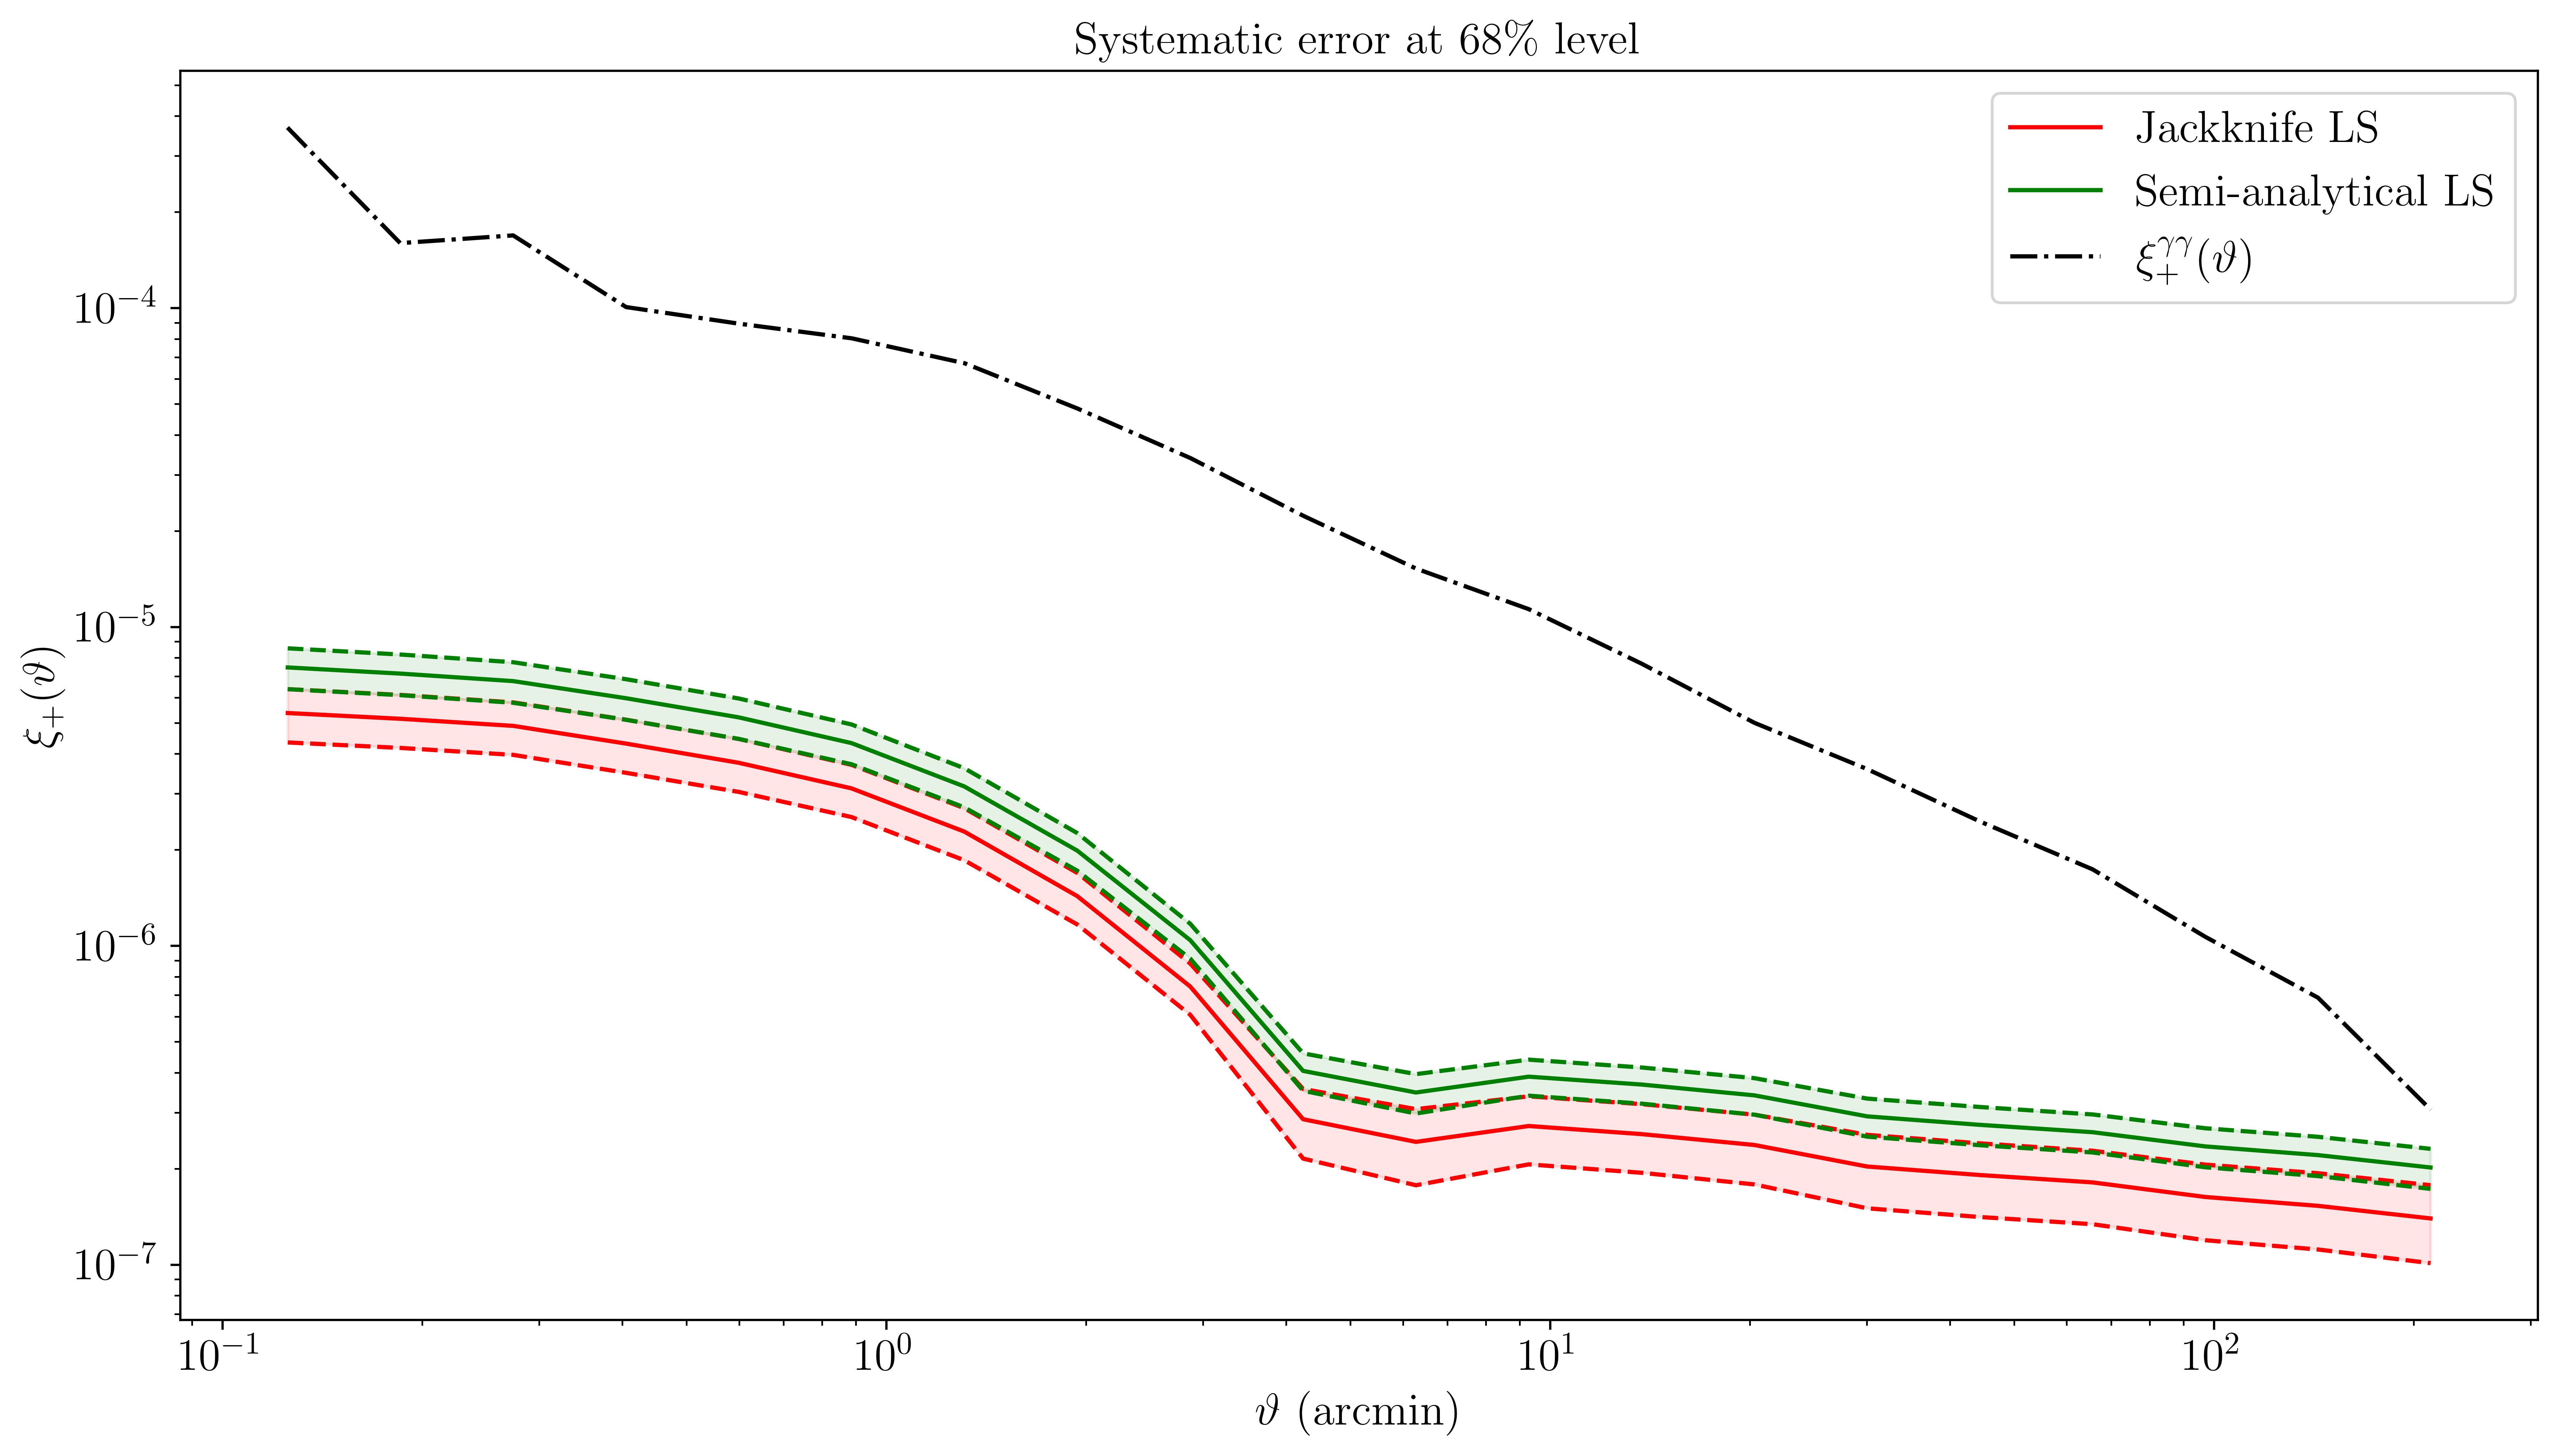

In [18]:
#plot of the xi_sys
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # You can change this font if you prefer
    "axes.labelsize": 16,  # Adjust as needed
    "axes.titlesize": 16,  # Adjust as needed
    "xtick.labelsize": 16,  # Adjust as needed
    "ytick.labelsize": 16,  # Adjust as needed
    "legend.fontsize": 16,  # Adjust as needed
    "figure.figsize": (15, 8),  # Adjust as needed
    "figure.dpi": 600  # Adjust as needed
})

base_dir = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/'

plt.figure()

samples = [samples_jk_lq, samples_th_lq]
colors = ['r', 'g']
labels = ['Jackknife LS', 'Semi-analytical LS']

for sample, color, label in zip(samples, colors, labels):
    quant = 0.84
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)
    for i in range(len(sample)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(sample[i])
        xi_psf_sys_samples = np.vstack((xi_psf_sys_samples, xi_psf_sys))
    
    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']
    plt.plot(theta, xi_psf_sys_mean, c=color, label=label)
    plt.plot(theta, xi_psf_sys_quant[0], c=color, ls='--')
    plt.plot(theta, xi_psf_sys_quant[1], c=color, ls='--')
    plt.fill_between(theta, xi_psf_sys_quant[0], xi_psf_sys_quant[1], color=color, alpha=0.1)

if os.path.exists(base_dir+'/xi_plus_'+version+'.fits'):
    xi_plus = fits.getdata(base_dir+'/xi_plus_'+version+'.fits')
    plt.plot(xi_plus['ANG'], xi_plus['VALUE'], c='k', ls='-.', label=r"$\xi^{\gamma \gamma}_+(\vartheta)$")
else:
    raise ValueError("xi_plus file not found")

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\vartheta$ (arcmin)')
plt.ylabel(r'$\xi_{+}(\vartheta)$')
plt.legend()
plt.title("Systematic error at 68\% level")
plt.show()